# **This notebook will:**



load the clean modeling file

remove duplicate text columns

define features and target

train baseline models

evaluate them

show feature importance



# **Cell 1 — Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# **Cell 2 — Load data**

In [2]:
CSV_PATH = "/content/nri_wildfire_county_model_base.csv"

df = pd.read_csv(CSV_PATH, dtype={"county_fips": str})
df["county_fips"] = df["county_fips"].str.zfill(5)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Shape: (3144, 17)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,state_pred,county_pred,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita
0,Alabama,Autauga,01001,3.626224e+04,10.498560,Alabama,Autauga,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,Alabama,Baldwin,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078
2,Alabama,Barbour,01005,2.590932e+04,10.162397,Alabama,Barbour,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550
3,Alabama,Bibb,01007,3.260612e+04,10.392286,Alabama,Bibb,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103
4,Alabama,Blount,01009,9.336726e+04,11.444307,Alabama,Blount,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271



Columns:
['state', 'county', 'county_fips', 'wildfire_eal', 'log_wildfire_eal', 'state_pred', 'county_pred', 'population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita']


# **Cell 3 — Drop duplicate non-model columns**

In [3]:
drop_cols = [c for c in ["state_pred", "county_pred"] if c in df.columns]
df = df.drop(columns=drop_cols)

print("Dropped duplicate columns:", drop_cols)
print("New shape:", df.shape)
display(df.head())


Dropped duplicate columns: ['state_pred', 'county_pred']
New shape: (3144, 15)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271


# **Cell 4 — Define target and features**

In [4]:
TARGET = "log_wildfire_eal"

feature_cols = [
    "population",
    "building_value",
    "agriculture_value",
    "area_sq_mi",
    "social_vulnerability_score",
    "community_resilience_score",
    "population_density",
    "building_value_density",
    "agriculture_value_density",
    "building_value_per_capita",
]

X = df[feature_cols].copy()
y = df[TARGET].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(feature_cols)


Feature matrix shape: (3144, 10)
Target shape: (3144,)

Feature columns:
['population', 'building_value', 'agriculture_value', 'area_sq_mi', 'social_vulnerability_score', 'community_resilience_score', 'population_density', 'building_value_density', 'agriculture_value_density', 'building_value_per_capita']


# **Cell 5 — Quick target plot**

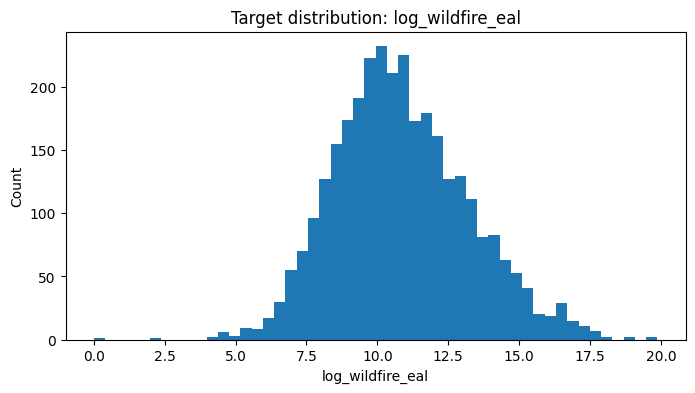

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(y, bins=50)
plt.xlabel("log_wildfire_eal")
plt.ylabel("Count")
plt.show()


# **Cell 6 — Train/test split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (2515, 10)
X_test: (629, 10)
y_train: (2515,)
y_test: (629,)


# **Cell 7 — Preprocessing**

In [7]:
numeric_features = feature_cols

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)


# **Cell 8 — Define models**

In [8]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3
    )
}


# **Cell 9 — Train and evaluate**

In [10]:
results = []

fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df)


,model,MAE,RMSE,R2
2,RandomForest,1.292024,1.674776,0.483224
3,GradientBoosting,1.322284,1.724024,0.452385
1,Ridge,1.602505,2.146966,0.150742
0,LinearRegression,1.602485,2.147108,0.150630


# **Cell 10 — 5-fold cross-validation**

In [11]:
cv_results = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    r2_scores = cross_val_score(pipe, X, y, cv=kf, scoring="r2", n_jobs=-1)
    mse_scores = -cross_val_score(
        pipe, X, y, cv=kf,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    rmse_scores = np.sqrt(mse_scores)

    cv_results.append({
        "model": name,
        "CV_R2_mean": r2_scores.mean(),
        "CV_R2_std": r2_scores.std(),
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_R2_mean", ascending=False)
display(cv_results_df)


,model,CV_R2_mean,CV_R2_std,CV_RMSE_mean,CV_RMSE_std
2,RandomForest,0.503883,0.017263,1.661251,0.028285
3,GradientBoosting,0.489404,0.021295,1.685123,0.029782
1,Ridge,0.151237,0.121947,2.169992,0.179162
0,LinearRegression,0.148871,0.126586,2.172727,0.184603


# **Cell 11 — Predicted vs actual for best model**

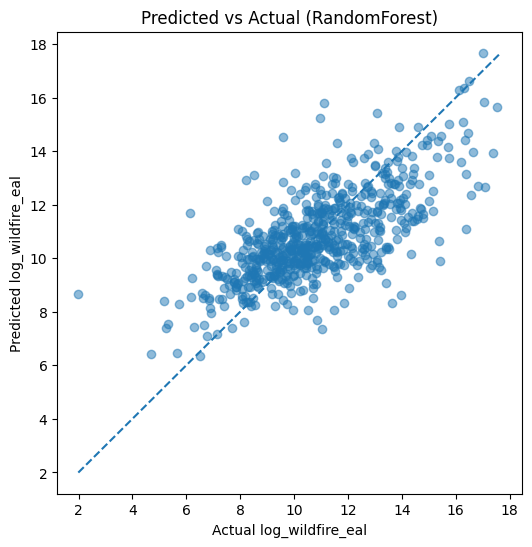

In [12]:
best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_model_name]

y_pred_best = best_pipe.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.xlabel("Actual log_wildfire_eal")
plt.ylabel("Predicted log_wildfire_eal")

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()


# **Cell 12 — Residual plot**

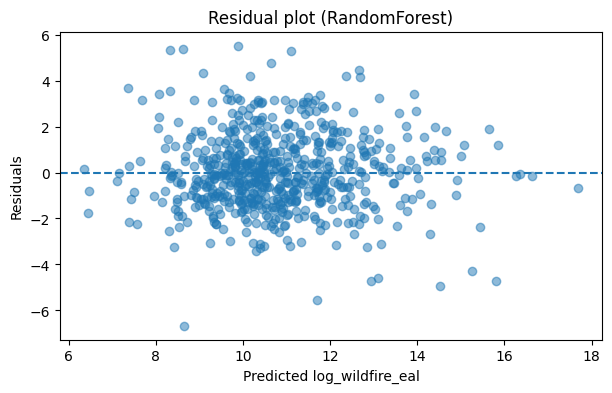

In [13]:
residuals = y_test - y_pred_best

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log_wildfire_eal")
plt.ylabel("Residuals")
plt.show()


# **Cell 13 — Feature importance for tree model**

,feature,importance
3,area_sq_mi,0.392515
5,community_resilience_score,0.110084
0,population,0.083992
9,building_value_per_capita,0.072952
8,agriculture_value_density,0.069897
4,social_vulnerability_score,0.068564
2,agriculture_value,0.059402
1,building_value,0.054632
6,population_density,0.044628
7,building_value_density,0.043336


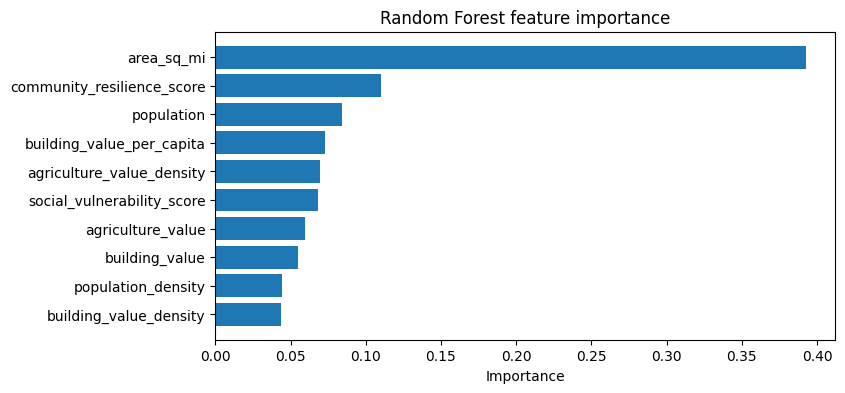

In [14]:
rf_pipe = fitted_pipelines["RandomForest"]
rf_model = rf_pipe.named_steps["model"]

importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 4))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.show()


# **Cell 14 — Save predictions**

In [15]:
pred_out = X_test.copy()
pred_out["actual_log_wildfire_eal"] = y_test.values
pred_out["predicted_log_wildfire_eal"] = y_pred_best

OUT_PATH = "/content/wildfire_risk_baseline_predictions.csv"
pred_out.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)


Saved: /content/wildfire_risk_baseline_predictions.csv


# **Cell 15 — Optional: recover original dollar scale**

In [16]:
pred_out["actual_wildfire_eal"] = np.expm1(pred_out["actual_log_wildfire_eal"])
pred_out["predicted_wildfire_eal"] = np.expm1(pred_out["predicted_log_wildfire_eal"])

display(pred_out.head())


,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita,actual_log_wildfire_eal,predicted_log_wildfire_eal,actual_wildfire_eal,predicted_wildfire_eal
2993,7802,2.217567e+09,2610595.0,323.711289,33.269720,49.332061,24.101724,6.850447e+06,8064.578178,2.842306e+05,8.164677,8.578312,3513.585164,5314.125576
2971,13347,3.360830e+09,6091081.0,1439.889378,40.108142,21.882952,9.269462,2.334089e+06,4230.242331,2.518041e+05,12.614285,12.804295,300824.178107,363775.564149
1064,31629,7.710983e+09,66164981.0,343.604688,40.553435,64.249364,92.050549,2.244144e+07,192561.345497,2.437947e+05,9.454494,9.163742,12764.405796,9543.701914
1987,6379,7.321097e+09,277399333.0,1714.834748,31.106870,58.746819,3.719892,4.269273e+06,161764.469344,1.147687e+06,13.505041,13.005501,733101.683265,444852.718258
2990,94158,2.250201e+10,3458170.0,290.924398,59.160305,73.854962,323.651095,7.734659e+07,11886.833910,2.389814e+05,11.879688,10.511084,144304.576582,36719.254842


In [ ]:
# ============================================================
# Export helper functions with no titles in exported tables/figures
# ============================================================
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def save_dataframe_as_pdf_no_title(df, path, rows_per_page=25, fontsize=8, fig_width=14):
    """Save a pandas DataFrame as a clean multi-page PDF table without a table title."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df_to_save = df.copy()

    for col in df_to_save.columns:
        if pd.api.types.is_numeric_dtype(df_to_save[col]):
            df_to_save[col] = df_to_save[col].apply(
                lambda x: f"{x:,.4f}" if pd.notna(x) and abs(x) < 100000 else f"{x:,.0f}" if pd.notna(x) else ""
            )
        else:
            df_to_save[col] = df_to_save[col].astype(str)

    with PdfPages(path) as pdf:
        for start in range(0, len(df_to_save), rows_per_page):
            page_df = df_to_save.iloc[start:start + rows_per_page]
            fig_height = max(3.8, 0.42 * len(page_df) + 1.2)
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            ax.axis("off")
            table = ax.table(
                cellText=page_df.values,
                colLabels=page_df.columns,
                cellLoc="center",
                loc="center"
            )
            table.auto_set_font_size(False)
            table.set_fontsize(fontsize)
            table.scale(1, 1.25)
            for key, cell in table.get_celld().items():
                cell.set_linewidth(0.4)
                if key[0] == 0:
                    cell.set_text_props(weight="bold")
                    cell.set_facecolor("#eeeeee")
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
    print(f"Saved table PDF: {path}")
    return path

# ============================================================
# Notebook 3 exports: baseline wildfire risk regression
# No titles are added to exported tables or figures.
# ============================================================
EXPORT_DIR = Path("/content/thesis_exports/notebook3_baseline_modeling_no_titles")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

test_results_export = results_df.copy().sort_values("R2", ascending=False)
display(test_results_export)
save_dataframe_as_pdf_no_title(test_results_export, EXPORT_DIR / "table_1_test_set_baseline_model_comparison.pdf", rows_per_page=20, fontsize=9, fig_width=12)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = test_results_export.sort_values("R2", ascending=True)
ax.barh(plot_df["model"], plot_df["R2"])
ax.set_xlabel("Test $R^2$")
ax.set_ylabel("Model")
for i, value in enumerate(plot_df["R2"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.set_xlim(0, plot_df["R2"].max() + 0.08)
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_1_test_r2_baseline_model_comparison.pdf"
fig_path_png = EXPORT_DIR / "figure_1_test_r2_baseline_model_comparison.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = test_results_export.sort_values("RMSE", ascending=False)
ax.barh(plot_df["model"], plot_df["RMSE"])
ax.set_xlabel("Test RMSE")
ax.set_ylabel("Model")
for i, value in enumerate(plot_df["RMSE"]):
    ax.text(value + 0.02, i, f"{value:.3f}", va="center", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.set_xlim(0, plot_df["RMSE"].max() + 0.35)
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_2_test_rmse_baseline_model_comparison.pdf"
fig_path_png = EXPORT_DIR / "figure_2_test_rmse_baseline_model_comparison.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

cv_results_export = cv_results_df.copy().sort_values("CV_R2_mean", ascending=False)
display(cv_results_export)
save_dataframe_as_pdf_no_title(cv_results_export, EXPORT_DIR / "table_2_cross_validation_baseline_model_comparison.pdf", rows_per_page=20, fontsize=9, fig_width=12)


# Combined baseline performance summary table
combined_summary = test_results_export.merge(
    cv_results_export,
    on="model",
    how="left"
)

combined_summary = combined_summary[
    [
        "model",
        "MAE",
        "RMSE",
        "R2",
        "CV_R2_mean",
        "CV_R2_std",
        "CV_RMSE_mean",
        "CV_RMSE_std"
    ]
].copy()

combined_summary = combined_summary.sort_values("CV_R2_mean", ascending=False)

display(combined_summary)

save_dataframe_as_pdf_no_title(
    combined_summary,
    EXPORT_DIR / "table_3_combined_baseline_model_performance_summary.pdf",
    rows_per_page=20,
    fontsize=8,
    fig_width=14
)


fig, ax = plt.subplots(figsize=(9, 5.5))
plot_df = cv_results_export.sort_values("CV_R2_mean", ascending=True)
ax.barh(plot_df["model"], plot_df["CV_R2_mean"])
ax.set_xlabel("Mean CV $R^2$", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
for i, value in enumerate(plot_df["CV_R2_mean"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlim(0, plot_df["CV_R2_mean"].max() + 0.08)
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_3_cv_r2_baseline_model_comparison.pdf"
fig_path_png = EXPORT_DIR / "figure_3_cv_r2_baseline_model_comparison.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_df = cv_results_export.sort_values("CV_RMSE_mean", ascending=False)
ax.barh(plot_df["model"], plot_df["CV_RMSE_mean"])
ax.set_xlabel("Mean CV RMSE", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
for i, value in enumerate(plot_df["CV_RMSE_mean"]):
    ax.text(value + 0.03, i, f"{value:.3f}", va="center", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlim(0, plot_df["CV_RMSE_mean"].max() + 0.35)
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_4_cv_rmse_baseline_model_comparison.pdf"
fig_path_png = EXPORT_DIR / "figure_4_cv_rmse_baseline_model_comparison.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, y_pred_best, alpha=0.55, edgecolor="black")
ax.set_xlabel("Actual log_wildfire_eal", fontsize=11)
ax.set_ylabel("Predicted log_wildfire_eal", fontsize=11)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1.5)
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_5_predicted_vs_actual_best_model.pdf"
fig_path_png = EXPORT_DIR / "figure_5_predicted_vs_actual_best_model.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

residuals = y_test - y_pred_best
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(y_pred_best, residuals, alpha=0.55, edgecolor="black")
ax.axhline(0, linestyle="--", linewidth=1.5)
ax.set_xlabel("Predicted log_wildfire_eal", fontsize=11)
ax.set_ylabel("Residuals", fontsize=11)
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_6_residual_plot_best_model.pdf"
fig_path_png = EXPORT_DIR / "figure_6_residual_plot_best_model.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()

rf_pipe = fitted_pipelines["RandomForest"]
rf_model = rf_pipe.named_steps["model"]
importance_df = pd.DataFrame({"feature": feature_cols, "importance": rf_model.feature_importances_}).sort_values("importance", ascending=False)
display(importance_df)
importance_df.to_csv(EXPORT_DIR / "table_3_random_forest_feature_importance.csv", index=False)
plot_df = importance_df.head(10).sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_xlabel("Importance", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
for i, value in enumerate(plot_df["importance"]):
    ax.text(value + 0.002, i, f"{value:.3f}", va="center", fontsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
fig_path_pdf = EXPORT_DIR / "figure_7_random_forest_feature_importance_top10.pdf"
fig_path_png = EXPORT_DIR / "figure_7_random_forest_feature_importance_top10.png"
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.show()
